# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [15]:
# TODO
print("so dong: ", df.shape[0], "so cot: ", df.shape[1])
print()
df.info()

so dong:  891 so cot:  15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [16]:
# TODO
missing = df.isnull().sum()

print("Missing value:")
print(missing[missing>0] if missing.sum()>0 else "Not columns missing value")
print()
print("Duplicate data:", df.duplicated().sum())

Missing value:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate data: 107


## A.3. Invalid values

In [17]:
# TODO
df
print("age <= 0:", (df['age']<=0).sum())
print("age is null", (df['age'].isnull().sum()))
print("deck is null", (df['deck'].isnull().sum()))
print("pclass <= 0:", (df['pclass']<=0).sum())
print("embarked is null", (df['embarked'].isnull().sum()))
print("alone is null", (df['alone'].isnull().sum()))



age <= 0: 0
age is null 177
deck is null 688
pclass <= 0: 0
embarked is null 2
alone is null 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [18]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
 15  family_size  891 non-null    int64  
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [20]:
cols = ['age', 'fare', 'family_size']
for col in cols:
    _mean = df[col].mean()
    _median = df[col].median()
    _mode = df[col].mode()[0]
    print(f"[{col}] Mean: {_mean: .2f} | Median: {_median: .2f} | Mode: {_mode: .2f}")

[age] Mean:  29.70 | Median:  28.00 | Mode:  24.00
[fare] Mean:  32.20 | Median:  14.45 | Mode:  8.05
[family_size] Mean:  1.90 | Median:  1.00 | Mode:  1.00


In [25]:
df.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [22]:
# TODO
df['age'].mean()

# mean_, median_, mode_ = df[col].mean(), df['col'].median(), df['col'].mode()[0]
# print(f"{col}: Mean={mean_:.2f}")

np.float64(29.69911764705882)

## Group 2 — Dispersion

In [ ]:
import statistics as stats 

In [27]:
# TODO
# var, std : cach xa mean k, lech nhieu hay it 
# IQR = Q3-Q1
# range = MAX- MIN

# CV 
dispersion_data={}
for col in ['age', 'fare', 'family_size']:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    dispersion_data[col] = {
        'Variance': s.var(),
        'Std Dev': s.std(),
        'Range': s.max() - s.min(),
        'IQR': q3 - q1,
        'CV (%)': (s.std() / s.mean()) *100
    }

pd.DataFrame(dispersion_data)

,age,fare,family_size
Variance,211.019125,2469.436846,2.603248
Std Dev,14.526497,49.693429,1.613459
Range,79.580000,512.329200,10.000000
IQR,17.875000,23.089600,1.000000
CV (%),48.912219,154.307253,84.713704


## Group 3 — Location and Shape

In [28]:
# TODO
# skewness , mean > median
# kurtosis ?? 

shape_data = {}

for col in ['age', 'fare', 'family_size']:
    s = df[col].dropna()
    shape_data[col] = {
        'Skewness': s.skew(),
        'Kurtosis': s.kurt()
    }


pd.DataFrame(shape_data)

,age,fare,family_size
Skewness,0.389108,4.787317,2.727441
Kurtosis,0.178274,33.398141,9.159666


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [29]:
# TODO
surv_pclass = df.groupby('pclass')['survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'})
surv_pclass['survival_rate'] = surv_pclass['survival_rate']*100
print(surv_pclass)

diff = surv_pclass.loc[1, 'survival_rate'] - surv_pclass.loc[3, 'survival_rate']
print(f"\n Hang 1 cao nhat ({surv_pclass.loc[1, 'survival_rate']: .2f}%), chenh lech {diff: .2f}% so voi Hang 3 thap nhat ({surv_pclass.loc[3, 'survival_rate']:.2f}%)")

        count  survival_rate
pclass                      
1         216      62.962963
2         184      47.282609
3         491      24.236253

 Hang 1 cao nhat ( 62.96%), chenh lech  38.73% so voi Hang 3 thap nhat (24.24%)


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

Ty le song sot theo Gioi Tinh
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

 Ty le song sot theo Gioi tinh & Hang ve
sex        female       male
pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


C:\Users\HP\AppData\Local\Temp\ipykernel_6372\2537580599.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='pclass', y ='survived', hue='sex', ci=None)


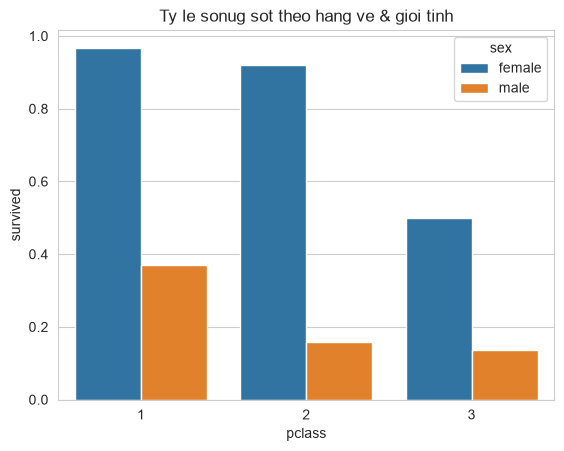

In [30]:
# TODO
print("Ty le song sot theo Gioi Tinh")
print(df.groupby('sex')['survived'].mean() *100)

print("\n Ty le song sot theo Gioi tinh & Hang ve")
print(df.pivot_table(index='pclass', columns='sex', values='survived', aggfunc='mean') * 100)

sns.barplot(data=df, x='pclass', y ='survived', hue='sex', ci=None)
plt.title('Ty le sonug sot theo hang ve & gioi tinh')
plt.show()

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

          count       mean        std  min      25%   50%   75%       max
survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


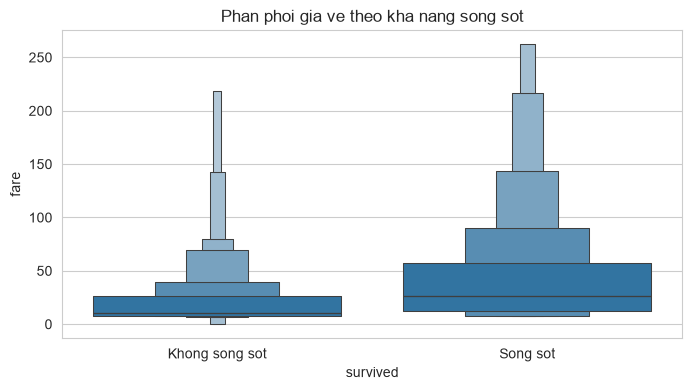

In [31]:
# TODO
print(df.groupby('survived')['fare'].describe())

plt.figure(figsize=(8,4))
sns.boxenplot(data=df, x='survived', y = 'fare', showfliers=False)
plt.title('Phan phoi gia ve theo kha nang song sot')
plt.xticks([0,1], ['Khong song sot', 'Song sot'])
plt.show()

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

             count       mean
family_size                  
1              537  30.353818
2              161  55.279503
3              102  57.843137
4               29  72.413793
5               15  20.000000
6               22  13.636364
7               12  33.333333
8                6   0.000000
11               7   0.000000


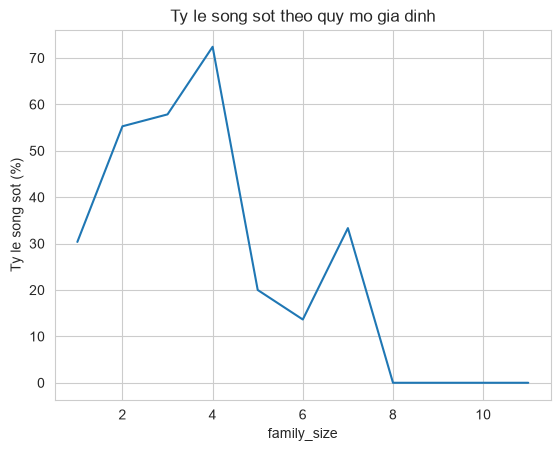

In [32]:
# TODO
surv_fam = df.groupby('family_size')['survived'].agg(['count', 'mean'])
surv_fam['mean'] = surv_fam['mean'] *100
print(surv_fam)

sns.lineplot(data=surv_fam, x=surv_fam.index, y = 'mean', markers='o')
plt.title('Ty le song sot theo quy mo gia dinh')
plt.ylabel('Ty le song sot (%)')
plt.show()

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [2]:
# TODO
surv_town = df.groupby('embark_town')['survived'].agg(['count', 'mean'])
surv_town['mean'] = surv_town['mean'] * 100
print(surv_town)

             count       mean
embark_town                  
Cherbourg      168  55.357143
Queenstown      77  38.961039
Southampton    644  33.695652


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Qua các phân tích trên em thấy được:

Phụ nữ và trẻ em có tỷ lệ sống sót áp đảo nam giới (74% so với 19%)

Vị thế xã hội và điều kiện kinh tế ảnh hưởng trực tiếp đến cơ hội sống sót: hành khách mua vé Hạng 1 và có giá vé cao có tỷ lệ sống sót cao gấp đôi so với hạng 3

Kích thước gia đình từ 2 -4 người thì có tỷ lệ sống sót cao hơn gia đình > 4 người. Nhờ ít người nên hỗ trợ nhau tốt hơn khi hoạn nạn

Cảng Cherbourg có tỷ lệ sống sót cao nhất trong các điểm suất phát vì tập trung lượng lớn hành khách Hạng 1 giàu có.